# How well does the proficient-fitted state space describe training?

The joint **left paw + wheel** states of the training sessions
(`data/training/left_paw_wheel_states_session_zscored/`) come from a model fitted on
**proficient** sessions only: the 319-session supersession
`data/session_zscored_supersession_wavelets_left_paw_wheel` (4 Aug 2026), clustered by the old
`segmentation/old_scritps/3.3_left_paw_wheel_clusters.ipynb`. Every training frame was then given
its nearest centroid, whether or not it is near ANY centroid.

If early training contains movements the proficient repertoire lacks, those frames are forced into
the nearest expert state, and the training trajectories partly reflect that forcing. The direct
test: **the distance from each frame to its nearest centroid, by stage**, compared with the
distances of the frames the model was fitted on.

**What this notebook does**
1. Refits that model exactly as the old notebook did (global z of the supersession → PCA to 95% →
   KMeans(8, seed 2024, 10 inits)), and checks that it reproduces the saved training states.
2. Labels every training and proficient frame, keeping the nearest and second-nearest centroid
   distances (in the model's PCA space).
3. Compares stages against the **reference**: the frames the model was fitted on.

**Stages** (`data/design_matrices/1_camera_setup/`), in the paper's timepoint colours:
`session_1` = Early learning, `last_training` = Late learning, `biased` = Pre-recording; the
proficient sessions (`data/`) = Proficient.

**Caveat.** The fitting frames are a density-weighted subsample, which over-represents common
movement. Their distances are therefore somewhat smaller than a uniform sample of the same
sessions would give. The proficient sessions, labelled in full, are the fair like-for-like
comparison; the fitting frames set the thresholds.

In [1]:
# ---- SHARED FIGURE STYLE ------------------------------------------------------------
import sys, pathlib, importlib

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
import paper_style
importlib.reload(paper_style)
ps = paper_style
ps.use('paper')
ROOT = str(_p) + '/'
HERE = ROOT + 'segmentation/1_camera_setup/learning/'

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from joblib import Parallel, delayed

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


In [2]:
"""DATA AND THE MODEL'S SETTINGS -- exactly those of the old 3.3_left_paw_wheel_clusters."""
DATA = ROOT + 'data/'
SUPERSESSION = DATA + 'session_zscored_supersession_wavelets_left_paw_wheel'
SAVED_TRAINING_STATES = DATA + 'training/left_paw_wheel_states_session_zscored/'
L_PAW = [f'l_paw_{a}{b}' for a in 'xy' for b in ['0.5', '1.0', '2.0', '4.0', '8.0']]
WHEEL = [f'avg_wheel_vel{b}' for b in ['0.5', '1.0', '2.0', '4.0', '8.0']]
FEATS = L_PAW + WHEEL
K, CUTOFF, SEED, N_INIT = 8, 0.95, 2024, 10

SETS = {   # stage -> (paw wavelet folder, wheel wavelet folder, design-matrix folder or None)
    'Early':      (DATA + 'training/left_paw_wavelets/', DATA + 'training/wheel_wavelets/',
                   DATA + 'design_matrices/1_camera_setup/session_1/'),
    'Late':       (DATA + 'training/left_paw_wavelets/', DATA + 'training/wheel_wavelets/',
                   DATA + 'design_matrices/1_camera_setup/last_training/'),
    'Pre-rec':    (DATA + 'training/left_paw_wavelets/', DATA + 'training/wheel_wavelets/',
                   DATA + 'design_matrices/1_camera_setup/biased/'),
    'Proficient': (DATA + 'paw_wavelets/', DATA + 'wheel_wavelets/', None),
}
STAGES = ps.TIMEPOINT_ORDER                       # Early, Late, Pre-rec, Proficient
STAGE_LABEL = {**ps.TIMEPOINT_LABEL, 'Reference': 'Reference (fitting frames)'}
REF_COLOR = '0.55'
CACHE = HERE + 'centroid_distance_by_stage_cache.npz'


def tags_of(stage):
    paw, wheel, dm = SETS[stage]
    have = ({f[len('paw_vel_wavelets_'):] for f in os.listdir(paw) if f.startswith('paw_vel_wavelets_')}
            & {f[len('wheel_vel_wavelets_'):] for f in os.listdir(wheel) if f.startswith('wheel_vel_wavelets_')})
    if dm:
        eids = {f.split('_')[2] for f in os.listdir(dm) if 'design_matrix' in f}
        have = {t for t in have if t[:36] in eids}
    return sorted(have)


TAGS = {s: tags_of(s) for s in STAGES}
print({s: len(t) for s, t in TAGS.items()})

{'Early': 49, 'Late': 55, 'Pre-rec': 117, 'Proficient': 332}


## 1. Refit the model and check it reproduces the saved training states

In [3]:
S = np.load(SUPERSESSION)
X_super = stats.zscore(S, axis=0)
pca = PCA(n_components=min(20, X_super.shape[1])).fit(X_super)
N_PC = int(np.where(np.cumsum(pca.explained_variance_ratio_) >= CUTOFF)[0][0] + 1)
P_super = pca.transform(X_super)[:, :N_PC]
km = KMeans(n_clusters=K, random_state=SEED, n_init=N_INIT).fit(P_super)
CENT = km.cluster_centers_
G_MU, G_SD = np.nanmean(X_super, axis=0), np.nanstd(X_super, axis=0)
print(f'supersession {S.shape} ({len(S) // 2000} sessions), {N_PC} PCs, inertia {km.inertia_:.4e}')


def load(stage, tag):
    paw, wheel, _ = SETS[stage]
    p = pd.read_parquet(paw + 'paw_vel_wavelets_' + tag, columns=['Bin'] + L_PAW)
    w = pd.read_parquet(wheel + 'wheel_vel_wavelets_' + tag, columns=['Bin'] + WHEEL)
    d = p.merge(w, on='Bin', how='inner')
    X = d[FEATS].to_numpy(float)
    ok = ~np.isnan(X).any(axis=1)
    return X[ok], d['Bin'].to_numpy()[ok]


def distances(X):
    """The old notebook's labelling: session z, then the supersession's global z, PCA, centroids."""
    Z = (stats.zscore(X, axis=0) - G_MU) / G_SD
    return cdist(pca.transform(Z)[:, :N_PC], CENT)


# reproduces the saved labels?
def agreement(tag):
    X, bins = load('Early' if tag in TAGS['Early'] else 'Late' if tag in TAGS['Late'] else 'Pre-rec', tag)
    f = SAVED_TRAINING_STATES + f'most_likely_states_{K}_{tag[37:]}{tag[:36]}.npy'
    if not os.path.exists(f):
        return np.nan
    saved = np.load(f)
    lab = distances(X).argmin(1)
    if len(saved[0]) != len(lab):
        return np.nan
    return float(np.mean(saved[0] == lab))


_check = [t for s in ('Early', 'Late', 'Pre-rec') for t in TAGS[s][:8]]
agree = np.array(Parallel(n_jobs=12)(delayed(agreement)(t) for t in _check))
print(f'refit vs saved training states, {np.isfinite(agree).sum()} sessions: '
      f'median agreement {np.nanmedian(agree):.4f}, min {np.nanmin(agree):.4f}')

supersession (638000, 15) (319 sessions), 11 PCs, inertia 3.5267e+06
refit vs saved training states, 24 sessions: median agreement 1.0000, min 1.0000


## 2. Distances for every frame

Per session: the nearest-centroid distance `d1` and the second-nearest `d2` of every frame,
summarised as a histogram and per-state statistics. The per-frame values are too large to keep.
The **reference** is the fitting frames' own `d1`; its 95th and 99th percentiles are the
thresholds.

In [4]:
D_REF = cdist(P_super, CENT)
ref_d1 = D_REF.min(1)
T95, T99 = np.percentile(ref_d1, [95, 99])
EDGES = np.linspace(0, max(15, np.percentile(ref_d1, 99.9) * 3), 301)
REF_STATE = D_REF.argmin(1)
print(f'reference d1: median {np.median(ref_d1):.2f}, p95 {T95:.2f}, p99 {T99:.2f}')


def summarise(stage, tag):
    X, _ = load(stage, tag)
    D = distances(X)
    o = np.sort(D, axis=1)
    d1, d2 = o[:, 0], o[:, 1]
    st = D.argmin(1)
    return dict(stage=stage, tag=tag, mouse=tag[37:], n=len(d1),
                hist=np.histogram(np.clip(d1, 0, EDGES[-1] - 1e-9), EDGES)[0],
                median_d1=np.median(d1), frac95=np.mean(d1 > T95), frac99=np.mean(d1 > T99),
                margin=np.median(d1 / d2),
                occ=np.bincount(st, minlength=K) / len(st),
                state_n=np.bincount(st, minlength=K),
                state_out99=np.bincount(st[d1 > T99], minlength=K),
                state_d1=np.bincount(st, weights=d1, minlength=K))


if os.path.exists(CACHE):
    R = list(np.load(CACHE, allow_pickle=True)['R'])
    print('read', CACHE)
else:
    R = Parallel(n_jobs=16)(delayed(summarise)(s, t) for s in STAGES for t in TAGS[s])
    np.savez(CACHE, R=np.array(R, dtype=object))
SES = pd.DataFrame([{k: v for k, v in r.items() if k in ('stage', 'tag', 'mouse', 'n', 'median_d1',
                                                         'frac95', 'frac99', 'margin')} for r in R])
SES.groupby('stage', sort=False)[['n', 'median_d1', 'frac95', 'frac99', 'margin']].median().round(3)

reference d1: median 1.47, p95 4.39, p99 6.73
read /home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/learning/centroid_distance_by_stage_cache.npz


,n,median_d1,frac95,frac99,margin
stage,,,,,
Early,87692.0,1.001,0.065,0.021,0.706
Late,104835.0,1.947,0.053,0.010,0.776
Pre-rec,129551.0,1.738,0.052,0.010,0.755
Proficient,267054.0,1.369,0.052,0.011,0.682


In [5]:
"""What the eight states are -- numbered BY VIGOR here, coloured by the paper's rule
(lightness = vigor, violet = left-paw-led, teal = wheel-led)."""
_vig = np.array([X_super[REF_STATE == s].mean() for s in range(K)])
_paw = np.array([X_super[REF_STATE == s][:, :10].mean() for s in range(K)])
_whl = np.array([X_super[REF_STATE == s][:, 10:].mean() for s in range(K)])
ORDER = np.argsort(_vig)                     # display state v = k-means cluster ORDER[v]
COL = dict(zip(ORDER, ps.state_palette(_vig[ORDER], (_paw - _whl)[ORDER], (310, ps.WHEEL_HUE))))
STATE_INFO = pd.DataFrame({'k-means label': ORDER, 'vigor': _vig[ORDER], 'paw power': _paw[ORDER],
                           'wheel power': _whl[ORDER],
                           'reference share': np.bincount(REF_STATE, minlength=K)[ORDER] / len(REF_STATE)})
STATE_INFO.index.name = 'state (by vigor)'
STATE_INFO.round(3)

,k-means label,vigor,paw power,wheel power,reference share
state (by vigor),,,,,
0,0,-0.627,-0.610,-0.662,0.360
1,7,-0.243,-0.256,-0.217,0.245
2,3,0.244,0.223,0.285,0.110
3,6,0.385,0.289,0.577,0.123
4,2,1.088,1.196,0.872,0.054
5,4,1.118,1.294,0.768,0.057
6,1,1.338,0.990,2.035,0.037
7,5,2.529,3.045,1.497,0.016


## 3. Figures

**A. Nearest-centroid distance, all frames per stage.** If the proficient-fitted states describe a
stage well, its curve lies on the proficient one. A heavier right tail means frames far from every
centroid.

not saved (ps.SAVE_FIGURES is False): figures/learning_centroid_distance_distribution_06-10-2026.png, figures/learning_centroid_distance_distribution_06-10-2026.svg   -- ps.saving(True) to write, or pass save=True


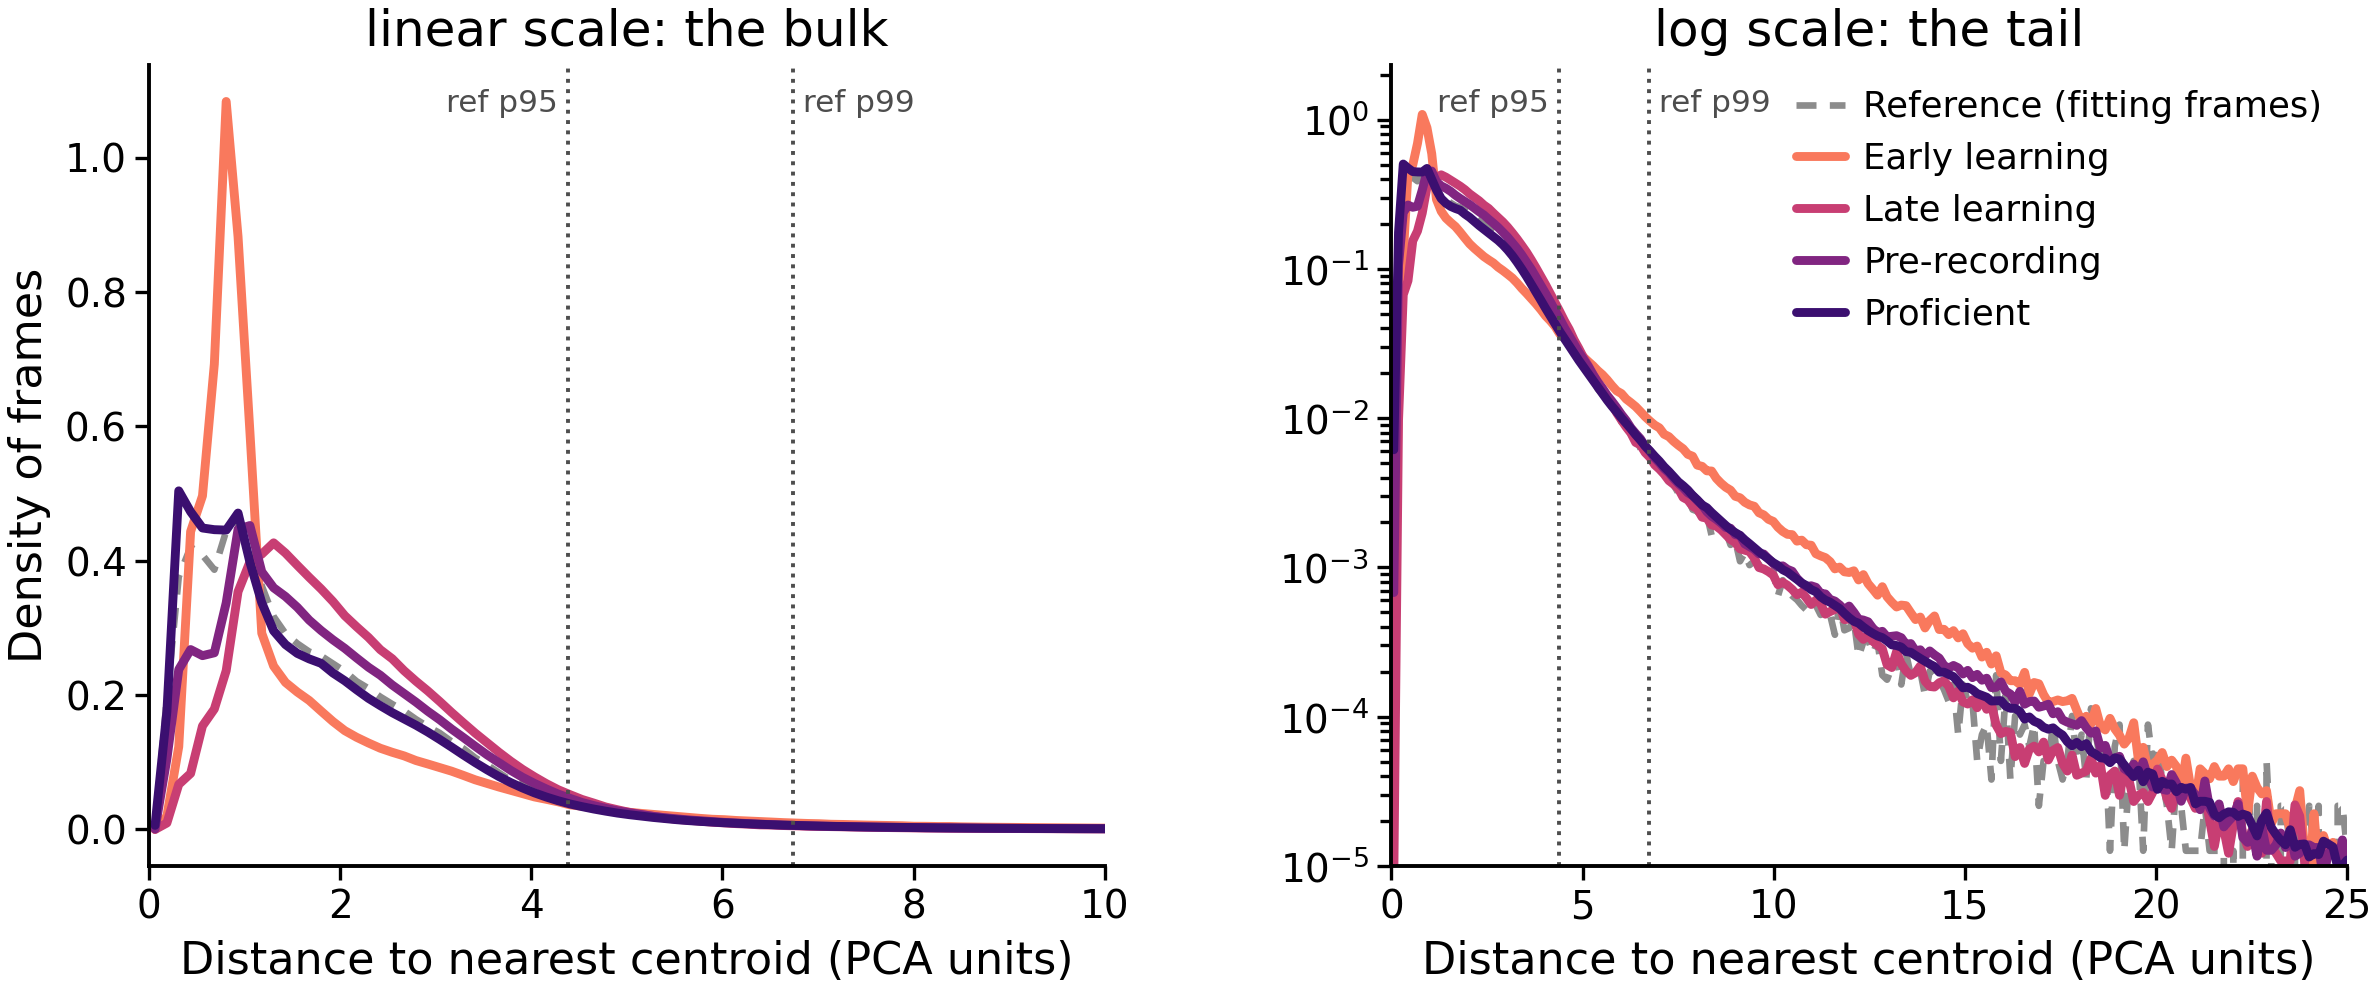

In [6]:
def pooled_hist(stage):
    h = np.sum([r['hist'] for r in R if r['stage'] == stage], axis=0).astype(float)
    return h / h.sum() / np.diff(EDGES)


mid = (EDGES[:-1] + EDGES[1:]) / 2
ref_h = np.histogram(np.clip(ref_d1, 0, EDGES[-1] - 1e-9), EDGES)[0].astype(float)
ref_h = ref_h / ref_h.sum() / np.diff(EDGES)

fig, axes = plt.subplots(1, 2, figsize=(ps.FIG['double'][0], 2.6), gridspec_kw=dict(wspace=0.3))
for ax, logy in zip(axes, (False, True)):
    ax.plot(mid, ref_h, color=REF_COLOR, lw=1.2, ls=(0, (3, 2)), label=STAGE_LABEL['Reference'])
    for s in STAGES:
        ax.plot(mid, pooled_hist(s), color=ps.TIMEPOINT[s], lw=1.6, label=STAGE_LABEL[s])
    for t, nm, ha in ((T95, 'ref p95 ', 'right'), (T99, ' ref p99', 'left')):
        ax.axvline(t, color='0.3', lw=0.7, ls=':')
        ax.text(t, 0.97, nm, transform=ax.get_xaxis_transform(), ha=ha, va='top',
                fontsize=plt.rcParams['font.size'] * 0.7, color='0.3')
    ax.set_xlabel('Distance to nearest centroid (PCA units)')
    ax.set_xlim(0, 10 if not logy else 25)
    if logy:
        ax.set_yscale('log'); ax.set_ylim(1e-5, None); ax.set_title('log scale: the tail')
    else:
        ax.set_title('linear scale: the bulk')
axes[0].set_ylabel('Density of frames')
axes[1].legend(frameon=False, fontsize=plt.rcParams['font.size'] * 0.8, loc='upper right')
ps.savefig(fig, 'learning_centroid_distance_distribution', svg=True)
plt.show()

**B. Per session: the share of frames beyond the reference's 99th percentile.** By construction
1% of the fitting frames lie beyond it (dotted line). One dot per session; bars are the median and
the bootstrap 95% CI over mice.

not saved (ps.SAVE_FIGURES is False): figures/learning_centroid_distance_sessions_06-10-2026.png, figures/learning_centroid_distance_sessions_06-10-2026.svg   -- ps.saving(True) to write, or pass save=True


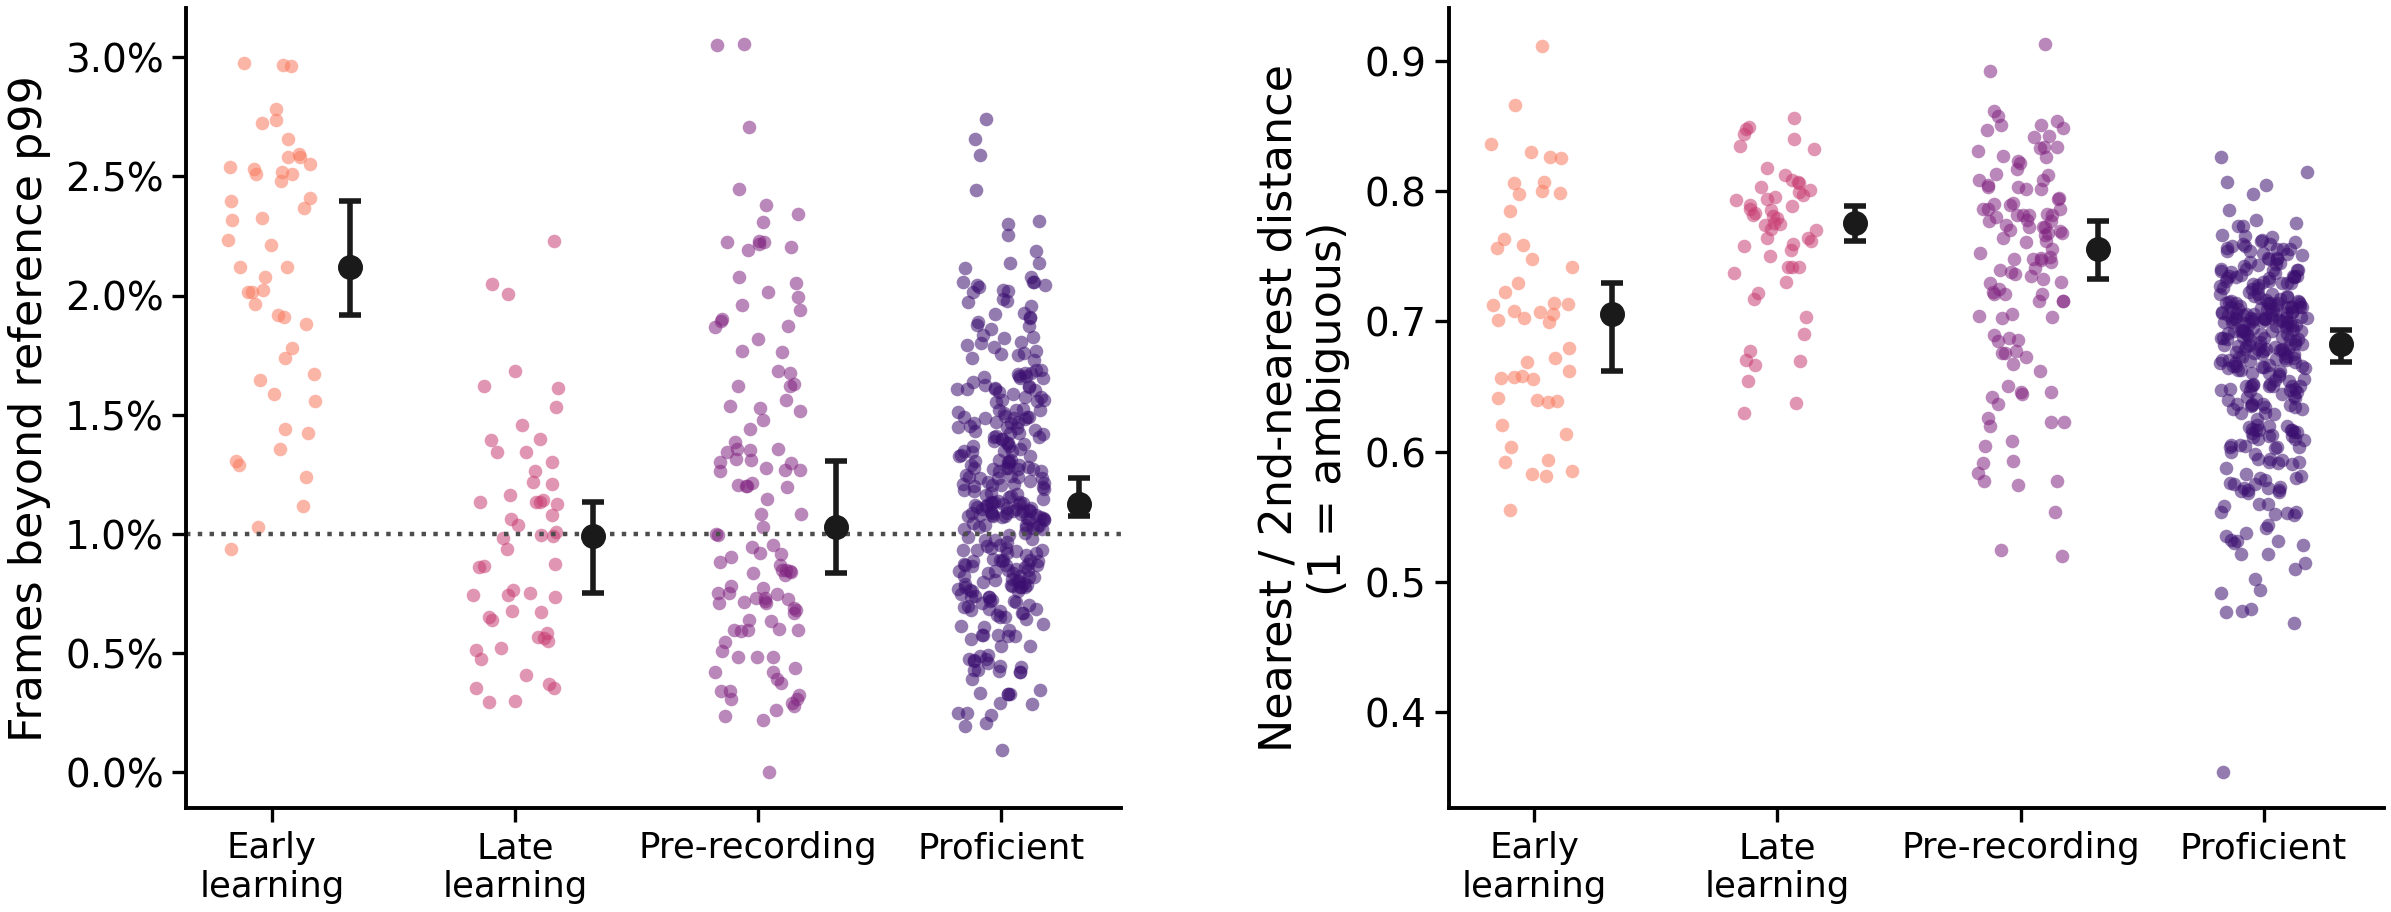

,frac99 median,lo,hi,sessions,mice
Early,0.0212,0.0192,0.0240,49,49
Late,0.0099,0.0075,0.0113,55,55
Pre-rec,0.0103,0.0083,0.0131,117,44
Proficient,0.0113,0.0107,0.0123,332,101


In [7]:
def mouse_ci(df, col, n_boot=2000, seed=0):
    """Median over sessions, with a CI from resampling MICE."""
    rng = np.random.default_rng(seed)
    g = {m: d[col].to_numpy() for m, d in df.groupby('mouse')}
    mice = list(g)
    boots = [np.median(np.concatenate([g[m] for m in rng.choice(mice, len(mice))])) for _ in range(n_boot)]
    return np.median(df[col]), *np.percentile(boots, [2.5, 97.5])


fig, axes = plt.subplots(1, 2, figsize=(ps.FIG['double'][0], 2.6), gridspec_kw=dict(wspace=0.35))
rng = np.random.default_rng(0)
for ax, (col, ylab, ref) in zip(axes, [('frac99', 'Frames beyond reference p99', 0.01),
                                       ('margin', 'Nearest / 2nd-nearest distance\n(1 = ambiguous)', None)]):
    for i, s in enumerate(STAGES):
        d = SES[SES['stage'] == s]
        ax.scatter(i + rng.uniform(-0.18, 0.18, len(d)), d[col], s=6, color=ps.TIMEPOINT[s],
                   alpha=0.55, linewidths=0)
        med, lo, hi = mouse_ci(d, col)
        ax.errorbar(i + 0.32, med, yerr=[[med - lo], [hi - med]], fmt='o', color='0.1', ms=3.5,
                    capsize=2, lw=1)
    if ref is not None:
        ax.axhline(ref, color='0.3', ls=':', lw=0.8)
    ax.set_xticks(range(len(STAGES)), [STAGE_LABEL[s].replace(' ', '\n', 1) for s in STAGES],
                  fontsize=plt.rcParams['font.size'] * 0.8)
    ax.set_ylabel(ylab)
axes[0].yaxis.set_major_formatter(lambda v, _: f'{v:.1%}')
ps.savefig(fig, 'learning_centroid_distance_sessions', svg=True)
plt.show()

summary = pd.DataFrame({s: dict(zip(['frac99 median', 'lo', 'hi'], mouse_ci(SES[SES['stage'] == s], 'frac99')))
                        for s in STAGES}).T
summary['sessions'] = SES.groupby('stage')['tag'].count()
summary['mice'] = SES.groupby('stage')['mouse'].nunique()
summary.round(4)

**C. Which states absorb the poorly described frames, and how occupancy shifts.** Left: per
state and stage, the share of that state's frames beyond the reference p99. Right: occupancy per
stage. A state that is both well occupied early and full of far frames is where the
proficient repertoire is being stretched to cover training behaviour.

not saved (ps.SAVE_FIGURES is False): figures/learning_centroid_distance_states_06-10-2026.png, figures/learning_centroid_distance_states_06-10-2026.svg   -- ps.saving(True) to write, or pass save=True


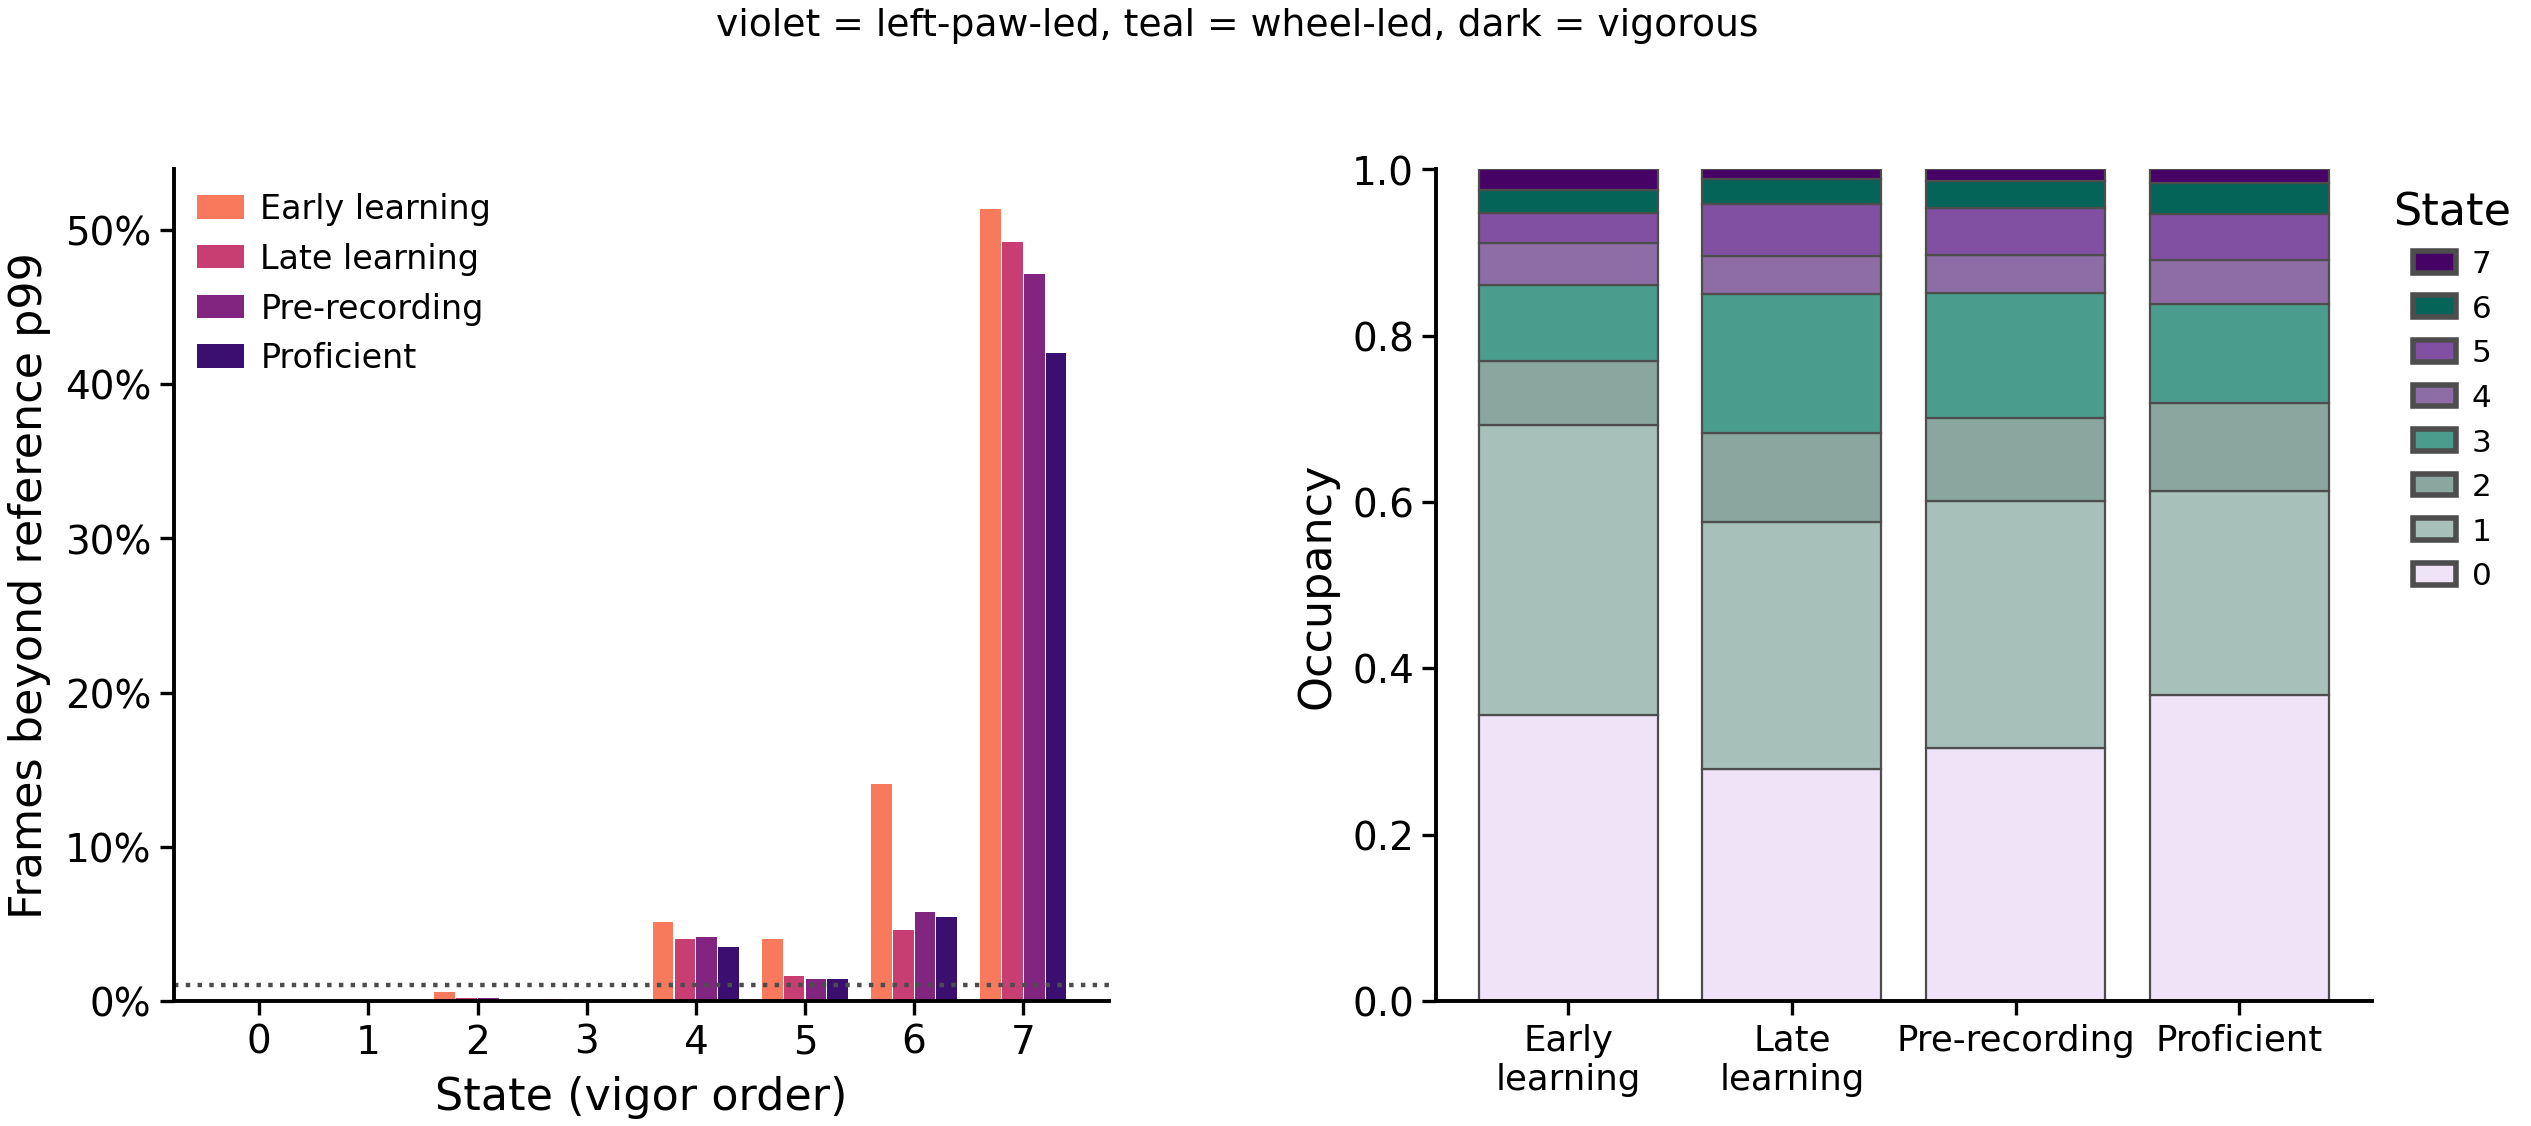

,0,1,2,3,4,5,6,7
Early,0.0,0.0,0.006,0.001,0.051,0.040,0.141,0.514
Late,0.0,0.0,0.002,0.000,0.040,0.016,0.046,0.492
Pre-rec,0.0,0.0,0.002,0.000,0.041,0.014,0.058,0.472
Proficient,0.0,0.0,0.001,0.000,0.035,0.014,0.054,0.420


In [8]:
def per_state(stage, key):
    return np.sum([r[key] for r in R if r['stage'] == stage], axis=0).astype(float)


OUT99 = pd.DataFrame({s: per_state(s, 'state_out99') / np.maximum(per_state(s, 'state_n'), 1)
                      for s in STAGES}).T[ORDER]
OCC = pd.DataFrame({s: np.mean([r['occ'] for r in R if r['stage'] == s], axis=0) for s in STAGES}).T[ORDER]
OUT99.columns = OCC.columns = range(K)

fig, axes = plt.subplots(1, 2, figsize=(ps.FIG['double'][0], 2.7), gridspec_kw=dict(wspace=0.35))
w = 0.8 / len(STAGES)
for j, s in enumerate(STAGES):
    axes[0].bar(np.arange(K) + (j - 1.5) * w, OUT99.loc[s], width=w * 0.95, color=ps.TIMEPOINT[s],
                label=STAGE_LABEL[s])
axes[0].axhline(0.01, color='0.3', ls=':', lw=0.8)
axes[0].set_xticks(range(K)); axes[0].set_xlabel('State (vigor order)')
axes[0].set_ylabel('Frames beyond reference p99')
axes[0].yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
axes[0].legend(frameon=False, fontsize=plt.rcParams['font.size'] * 0.75)
bottom = np.zeros(len(STAGES))
for v in range(K):
    axes[1].bar(range(len(STAGES)), OCC[v], bottom=bottom, color=COL[ORDER[v]], edgecolor='0.3', lw=0.4)
    bottom += OCC[v].to_numpy()
axes[1].set_xticks(range(len(STAGES)), [STAGE_LABEL[s].replace(' ', '\n', 1) for s in STAGES],
                   fontsize=plt.rcParams['font.size'] * 0.8)
axes[1].set_ylabel('Occupancy'); axes[1].set_ylim(0, 1)
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(facecolor=COL[ORDER[v]], edgecolor='0.3', label=str(v)) for v in range(K)][::-1],
               title='State', frameon=False, fontsize=plt.rcParams['font.size'] * 0.7,
               loc='upper left', bbox_to_anchor=(1.0, 1.0))
fig.suptitle('violet = left-paw-led, teal = wheel-led, dark = vigorous', y=1.03,
             fontsize=plt.rcParams['font.size'] * 0.85)
ps.savefig(fig, 'learning_centroid_distance_states', svg=True)
plt.show()
OUT99.round(3)

## What it shows (run 2026-10-06)

- **The refit is exact:** it reproduces the saved training states frame for frame (24 sessions checked, agreement 1.000).
- **Late learning and pre-recording are as well described as proficient:** about 1% of frames lie beyond
  the reference p99, as expected (Late 1.0% [0.8, 1.1], Pre-rec 1.0% [0.8, 1.3], Proficient 1.1% [1.1, 1.2];
  median over sessions, 95% CI over mice).
- **Early learning has twice the tail:** 2.1% [1.9, 2.4] of frames lie beyond p99. Its bulk is closer to the
  centroids than any other stage's (a sharp peak near the still state), but its tail is heavier.
- **The extra tail sits in the fast wheel-led state (6):** 14% of early-learning frames assigned to it are
  beyond p99, against about 5% in every later stage. The most vigorous state (7) is far from its centroid in
  every stage, including proficient (42–51%); it is a catch-all for the extreme tail, not a training effect.
- **Early learning also has more ambiguous assignments** than the later training stages (nearest /
  2nd-nearest ratio 0.71 vs 0.76–0.78), though similar to proficient.

**Reading:** the proficient-fitted states describe training well from late learning on. In the first
session, about 1% of frames (the excess over 1%), mostly fast wheel movements, are wheel behaviour
the expert repertoire lacks. They are forced into state 6, so early state-6 occupancy, and anything
built on it, should be read with that in mind.